# 一気通貫実装

In [17]:
DEFAULTS = {
    "svd_ratio": 0,                 # ← 可視化時はここを無視
    "non_iid_beta": 1,
}


In [18]:
import pandas as pd
import matplotlib.pyplot as plt


STYLE = {
    "nonlinear":               {"color": "#2ca02c", "linestyle": "-",  "marker": "o"},
    "nonlinear_zero":          {"color": "#2ca02c", "linestyle": "--", "marker": "o"},
    "laplacian_nonlinear":     {"color": "#1f77b4", "linestyle": "-",  "marker": "o"},
    "laplacian_nonlinear_zero":{"color": "#1f77b4", "linestyle": "--", "marker": "o"},
    "faster_gep":                     {"color": "#d62728", "linestyle": "-",  "marker": "o"},
    "imakura":                 {"color": "#d62728", "linestyle": ":",  "marker": "o"},
    "odc":                     {"color": "#d62728", "linestyle": "--", "marker": "o"},
    "targetvec_new":               {"color": "#d62728", "linestyle": "-.", "marker": "o"},
    "individual":              {"color": "gray",    "linestyle": "-",  "marker": None},
    "centralize":              {"color": "gray",    "linestyle": ":",  "marker": None},
    "federated_learning":                      {"color": "gray",    "linestyle": "--", "marker": "o"},
}


def visualize_with_defaults(
    csv_path,
    *,
    x_col,                     # 例: "svd_ratio"
    y_col="score_mean",
    xscale="linear",            # "linear" or "log"
    xlabel=None,
    title=None,
    defaults=DEFAULTS,
):
    """
    CSV を読み込み、
    - x_col 以外は DEFAULTS と一致する行のみ抽出
    - x_col vs y_col を可視化
    """

    # ------------------
    # Load
    # ------------------
    df = pd.read_csv(csv_path)

    # 数値化
    # for col in df.columns:
    #     try:
    #         df[col] = pd.to_numeric(df[col])
    #     except (ValueError, TypeError):
    #         # 数値に変換できない列はそのまま
    #         pass
    # ------------------
    # DEFAULTS フィルタ
    # ------------------
    for key, val in defaults.items():
        if key == x_col:
            continue              # ← 可視化軸は自由に動かす
        if key not in df.columns:
            continue
        if val is None:
            continue              # None は条件に使わない
        
        df = df[df[key] == val]
    # ------------------
    # zerosum → G_type 整理
    # ------------------
    if "zerosum" in df.columns:
        df.loc[
            (df["G_type"] == "nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "nonlinear_zero"

        df.loc[
            (df["G_type"] == "laplacian_nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "laplacian_nonlinear_zero"

    # ------------------
    # Plot
    # ------------------
    plt.figure(figsize=(9, 6))

    for g, gdf in df.groupby("G_type"):
        if g not in STYLE:
            continue
        gdf = gdf.dropna(subset=[x_col, y_col]).sort_values(x_col)
        st = STYLE[g]
        plt.plot(
            gdf[x_col],
            gdf[y_col],
            color=st["color"],
            linestyle=st["linestyle"],
            marker=st["marker"],
            label=g,
        )


    plt.xscale(xscale)
    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(y_col)

    if title:
        plt.title(title)

    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


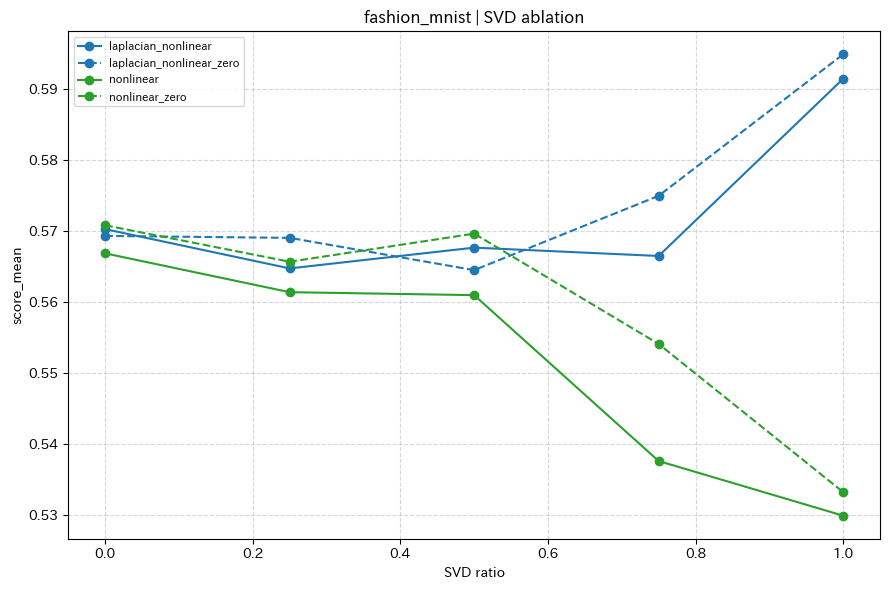

In [19]:
visualize_with_defaults(
    r"/Users/suetake/git-repos/takano_labo/dca/output/1218_bias_10/result_grid_fashion_mnist.csv",
    x_col="svd_ratio",
    xlabel="SVD ratio",
    title="fashion_mnist | SVD ablation"
)


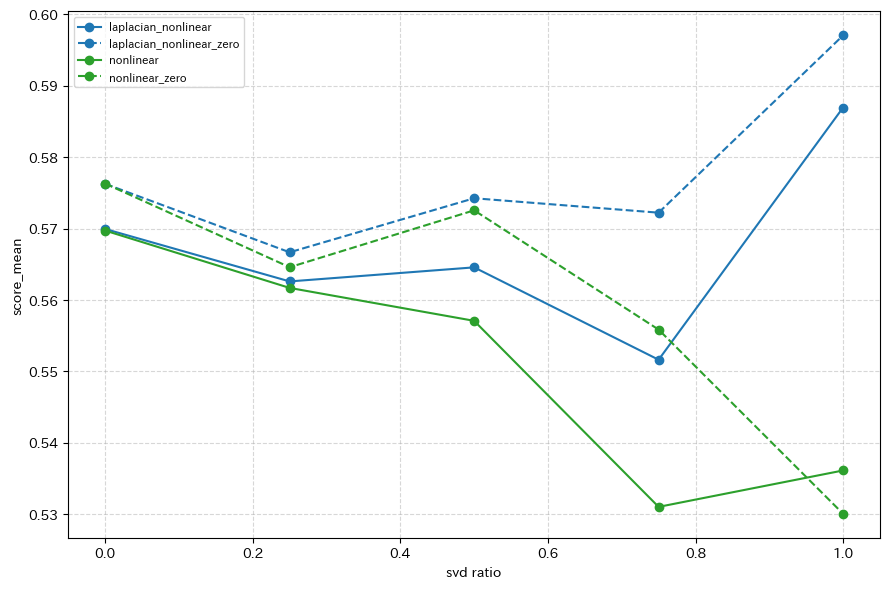

In [20]:
visualize_with_defaults(
    r"/Users/suetake/git-repos/takano_labo/dca/output/1218_bias/result_grid_fashion_mnist_svd_dir.csv",
    x_col="svd_ratio",
    xscale="linear",
    xlabel=r"svd ratio",
)


# これ

In [21]:
import pandas as pd

def load_and_filter(csv_path, *, x_col, defaults):
    df = pd.read_csv(csv_path)
    #df = pd.read_csv(csv_path, header=None)
    # ★ index が変なら必ずこれ ★
    #df = df.reset_index(drop=True)
    # 数値化（FutureWarning 回避）
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except (ValueError, TypeError):
            pass
    # ★ ここが重要 ★
    df["G_type"] = df["G_type"].astype(str)
    # DEFAULTS によるフィルタ（x_col 以外）
    for key, val in defaults.items():
        if key == x_col:
            continue
        if key not in df.columns or val is None:
            continue
        df = df[df[key] == val]

    if df.empty:
        raise ValueError("No data left after DEFAULTS filtering.")

    # zerosum → G_type 反映
    if "zerosum" in df.columns:
        df.loc[
            (df["G_type"] == "nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "nonlinear_zero"
        df.loc[
            (df["G_type"] == "laplacian_nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "laplacian_nonlinear_zero"

    return df




In [22]:
import matplotlib.pyplot as plt

STYLE = {
    "gep":        {"color": "#d62728", "linestyle": "-",  "marker": "o"},
    "imakura":    {"color": "#d62728", "linestyle": ":",  "marker": "d"},
    "odc":        {"color": "#d62728", "linestyle": "--", "marker": "s"},
    "targetvec":  {"color": "#d62728", "linestyle": "-.", "marker": "^"},

    "nonlinear":               {"color": "#2ca02c", "linestyle": "-",  "marker": "o"},
    "nonlinear_zero":          {"color": "#2ca02c", "linestyle": "--", "marker": "d"},
    "laplacian_nonlinear":     {"color": "#1f77b4", "linestyle": "-",  "marker": "o"},
    "laplacian_nonlinear_zero":{"color": "#1f77b4", "linestyle": "--", "marker": "d"},

    "individual":  {"color": "gray", "linestyle": "-",  "marker": None},
    "centralize":  {"color": "gray", "linestyle": ":",  "marker": None},
    #"fl":                      {"color": "gray",    "linestyle": "--", "marker": "o"},
}

def plot_filtered(
    df, *, x_col, y_col="score_mean",
    xscale="linear", xlabel=None, title=None
):
    plt.figure(figsize=(9, 6))

    for g, gdf in df.groupby("G_type"):
        if g not in STYLE:
            continue

        gdf = gdf.dropna(subset=[x_col, y_col]).sort_values(x_col)
        if gdf.empty:
            continue

        st = STYLE[g]
        plt.plot(
            gdf[x_col], gdf[y_col],
            color=st["color"],
            linestyle=st["linestyle"],
            marker=st["marker"],
            label=g
        )

    plt.xscale(xscale)
    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(y_col)

    # legend があるときだけ表示
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        plt.legend(fontsize=8)

    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [102]:
STYLE = {
    "individual":  {"name": "個別解析", "color": "gray", "linestyle": ":",  "marker": None},
    "centralize":  {"name": "集中解析", "color": "gray", "linestyle": "-",  "marker": None},

    "imakura":    {"name": "最小摂動問題（λ=∞, kernel=linear）", "color": "#d62728", "linestyle": ":",  "marker": "d"},
    "targetvec":  {"name": "目標ベクトル最適化（λ=0, kernel=linear）", "color": "#d62728", "linestyle": "-.", "marker": "^"},
    "gep":        {"name": "一般化固有値解法", "color": "#d62728", "linestyle": "-",  "marker": "o"},
    "odc":        {"name": "直交プロクラステス", "color": "#d62728", "linestyle": "--", "marker": "s"},

    "nonlinear":               {"name": "提案手法（λ=1, kernel=rbf）", "color": "#2ca02c", "linestyle": "-",  "marker": "o"},
    "nonlinear_zero":          {"name": "平均ゼロ化 提案手法（λ=1, kernel=rbf）", "color": "#2ca02c", "linestyle": "--", "marker": "d"},
    "laplacian_nonlinear":     {"name": "幾何的正則化付き 提案手法（λ=1, kernel=rbf）", "color": "#1f77b4", "linestyle": "-",  "marker": "o"},
    "laplacian_nonlinear_zero":{"name": "平均ゼロ化 幾何的正則化付き 提案手法（λ=1, kernel=rbf）", "color": "#1f77b4", "linestyle": "--", "marker": "d"},

    #"fl":                      {"color": "gray",    "linestyle": "--", "marker": "o"},
}

X_AXIS_STYLE = {
    "non_iid_beta": {
        "xlabel": r"データ非同一分布度合いを制御するパラメータ $\beta$",
        "xscale": "log",
        "title": "非同一分布度合いの影響",
    },
    "svd_ratio": {
        "xlabel": r"PCA による次元削減を行う機関比率",
        "xscale": "linear",
        "title": "線形次元削減 比率の影響",
    },
    "smote_ratio": {
        "xlabel": r"アンカーデータにおける公開データの比率",
        "xscale": "linear",
        "title": "アンカーデータの公開データ比率の影響",
    },
    "sub_dr_ratio": {
        "xlabel": r"PCA による次元削減を行う機関比率",
        "xscale": "linear",
        "title": "線形次元削減 比率の影響",
    },
}
Y_AXIS_STYLE = {
    "score_mean": {
        "ylabel": "分類精度（平均）",
    },
}

In [24]:
import os
print(os.getcwd())
print(os.path.exists(r"/Users/suetake/git-repos/takano_labo/dca/output/1218_bias/result_grid_fashion_mnist_svd_dir.csv"))


/Users/suetake/git-repos/takano_labo/dca/実験用
True


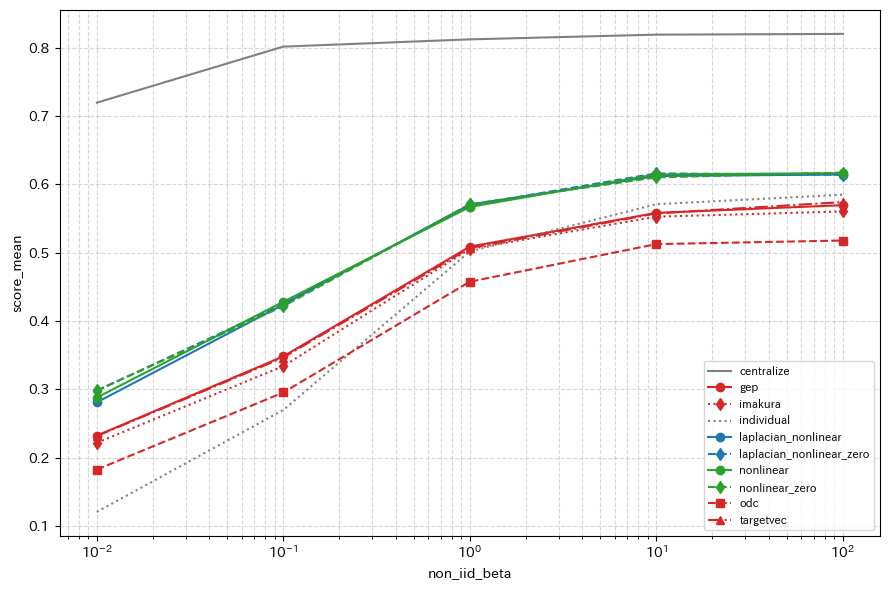

Index([  0,   1,   2,   3,   4,  25,  26,  27,  28,  29,  50,  51,  52,  53,
        54,  75,  76,  77,  78,  79, 100, 101, 102, 103, 104, 125, 126, 127,
       128, 129, 130, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145,
       146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 175,
       176, 187, 188, 189, 190, 191, 192, 193, 194, 195, 200, 201, 202, 203,
       204],
      dtype='int64')


In [25]:
df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_fashion_mnist_dir_svd.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)
df
plot_filtered(
    df,
    x_col="non_iid_beta",
    xscale="log",
    xlabel=r"non_iid_beta",
)
print(df.index)

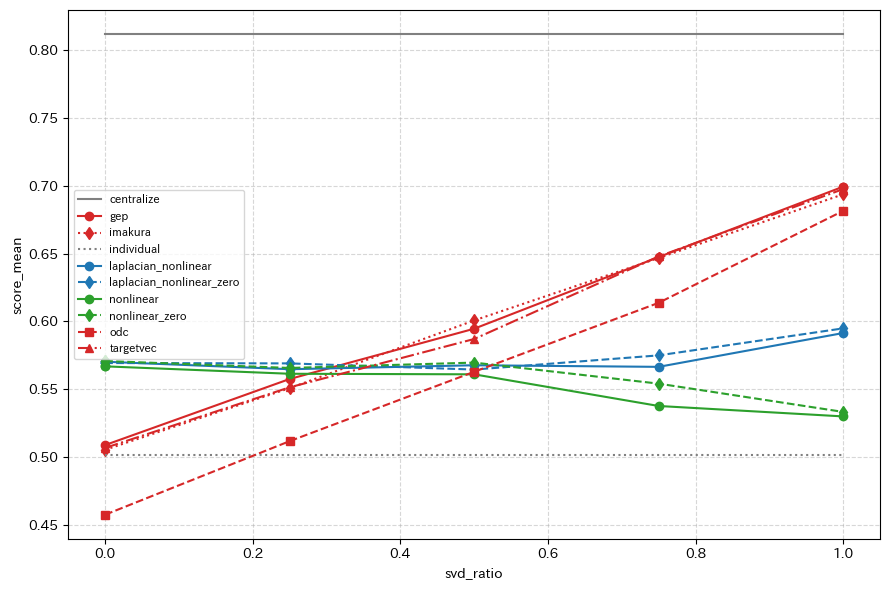

In [26]:
df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_fashion_mnist_dir_svd.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)
plot_filtered(
    df,
    x_col="svd_ratio",
    xscale="linear",
    xlabel=r"svd_ratio",
)

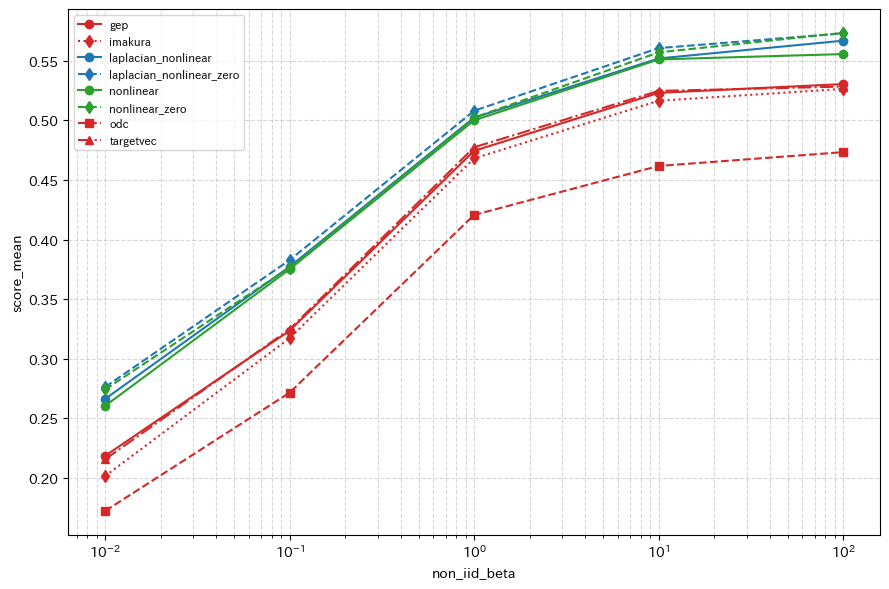

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71],
      dtype='int64')


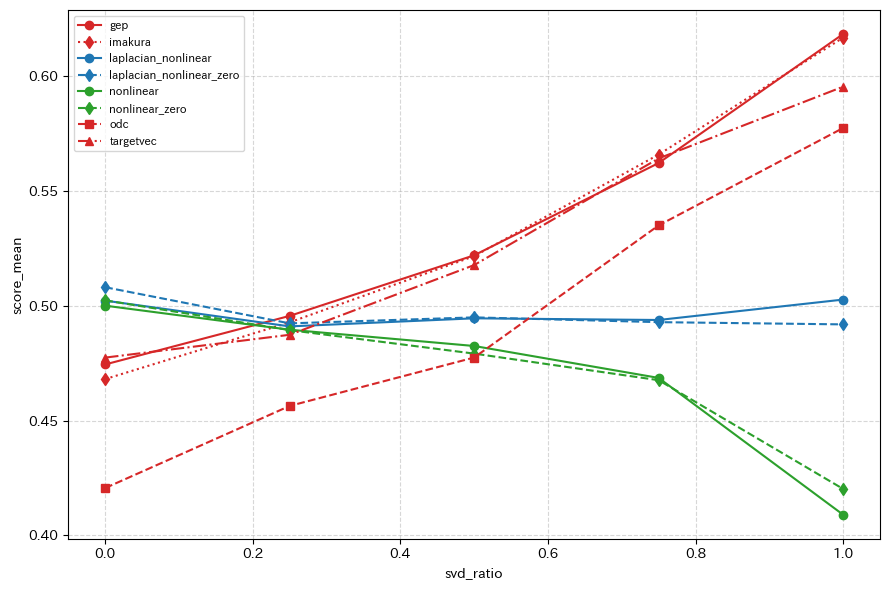

In [27]:
df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_mnist_dir_svd.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)
df
plot_filtered(
    df,
    x_col="non_iid_beta",
    xscale="log",
    xlabel=r"non_iid_beta",
)
print(df.index)

df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_mnist_dir_svd.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)
plot_filtered(
    df,
    x_col="svd_ratio",
    xscale="linear",
    xlabel=r"svd_ratio",
)

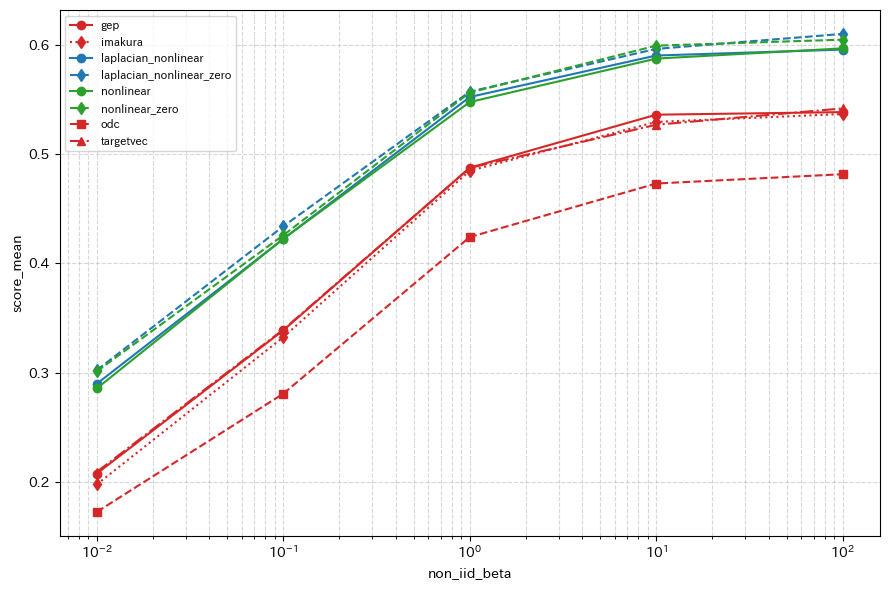

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71],
      dtype='int64')


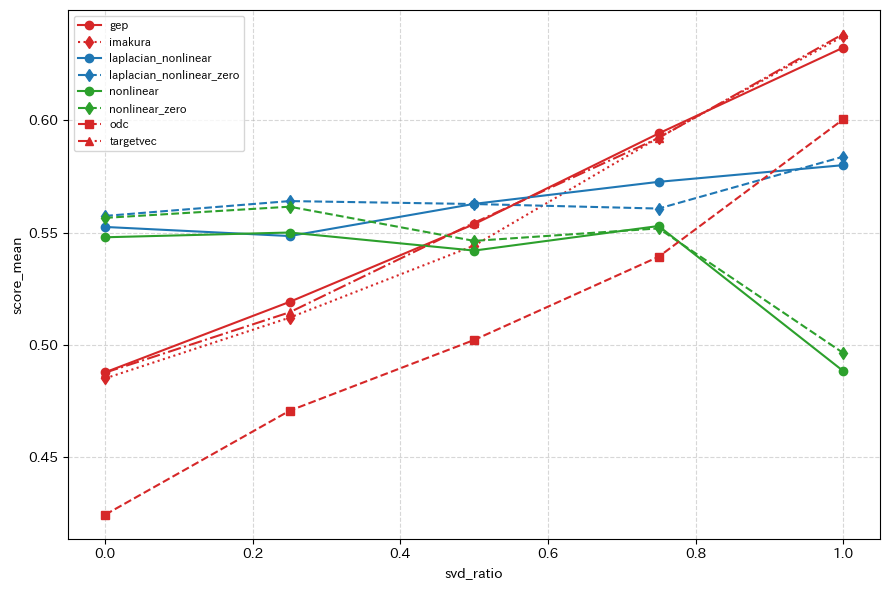

In [28]:
df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_mnist_dir_svd_public_1000.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)
df
plot_filtered(
    df,
    x_col="non_iid_beta",
    xscale="log",
    xlabel=r"non_iid_beta",
)
print(df.index)

df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_mnist_dir_svd_public_1000.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)
plot_filtered(
    df,
    x_col="svd_ratio",
    xscale="linear",
    xlabel=r"svd_ratio",
)

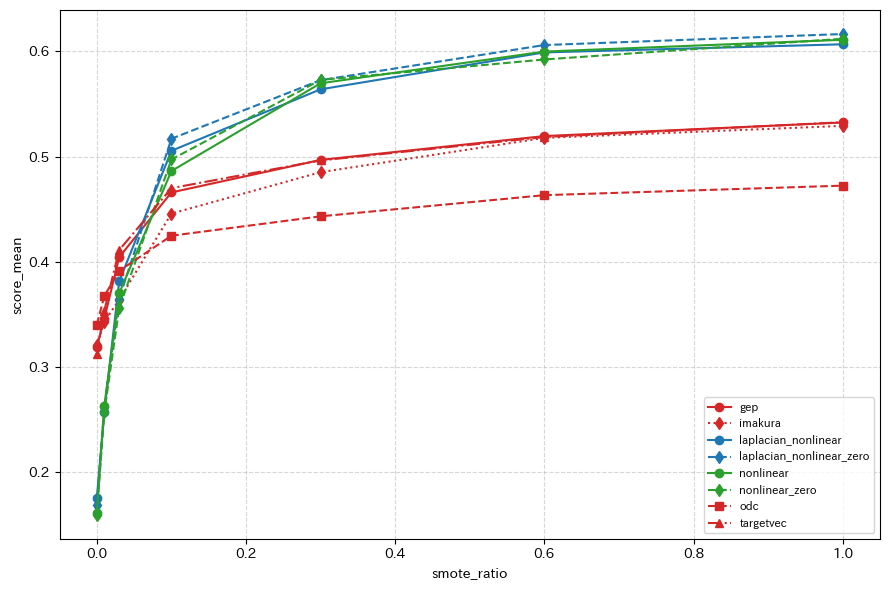

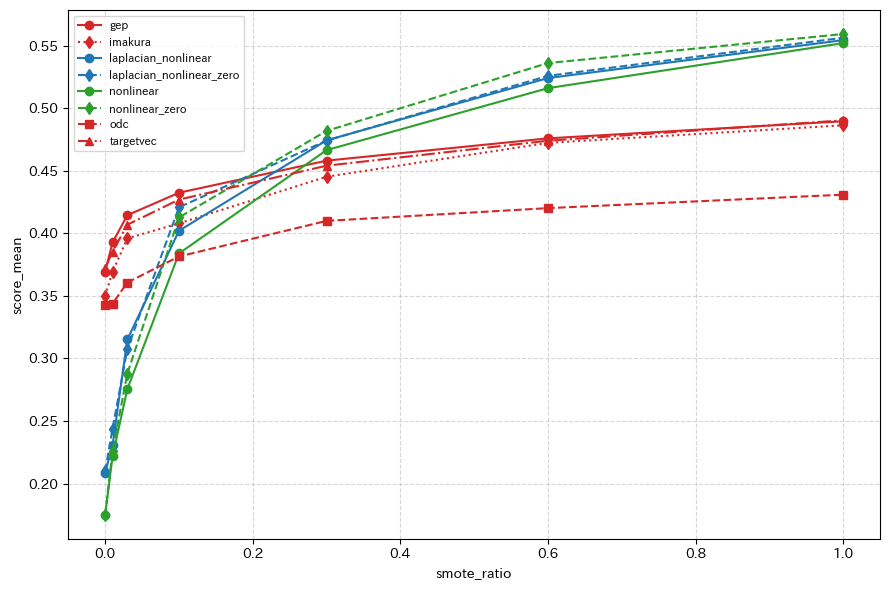

In [29]:
df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_fashion_mnist_anchor_concordance.csv",
    x_col="smote_ratio",
    defaults=DEFAULTS,
)

plot_filtered(
    df,
    x_col="smote_ratio",
    xscale="linear",
    xlabel=r"smote_ratio",
)

df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_mnist_anchor_concordance.csv",
    x_col="smote_ratio",
    defaults=DEFAULTS,
)

plot_filtered(
    df,
    x_col="smote_ratio",
    xscale="linear",
    xlabel=r"smote_ratio",
)

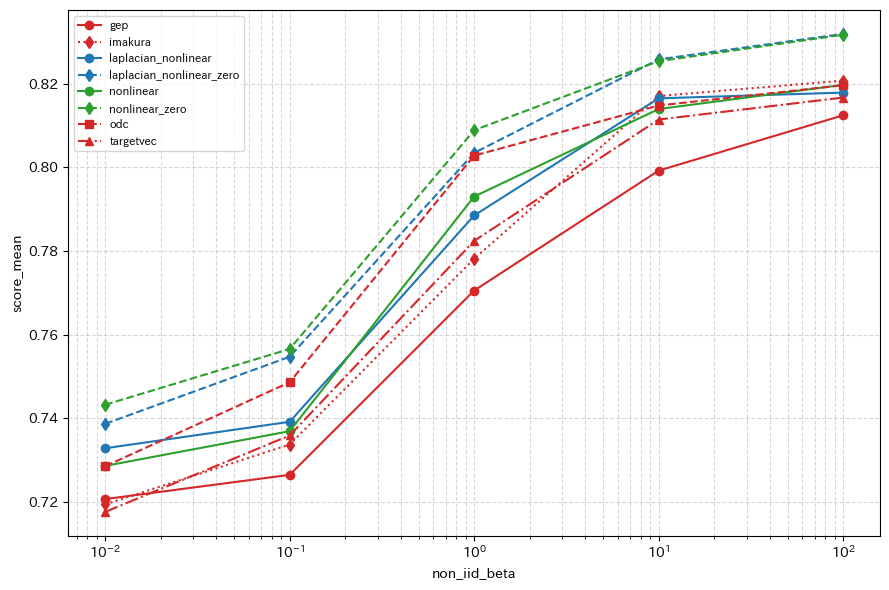

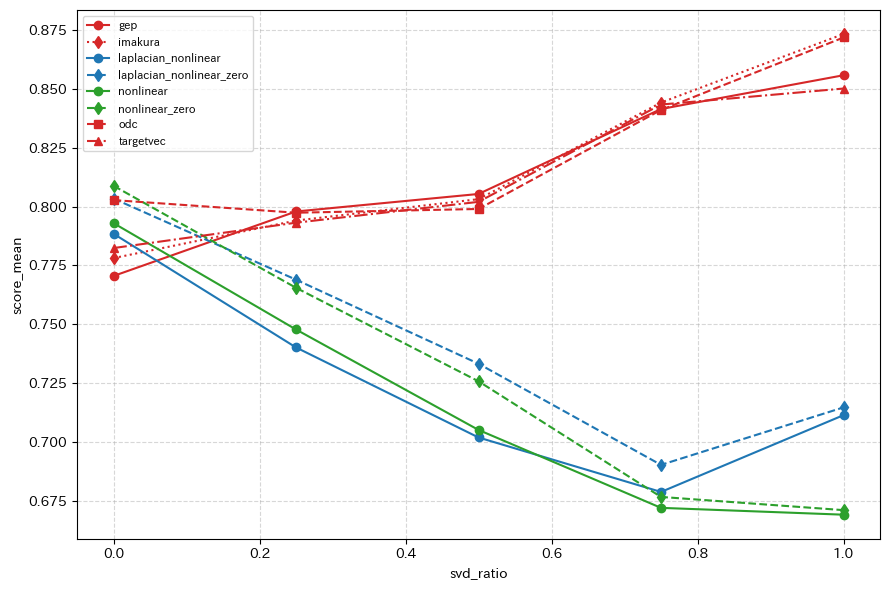

In [55]:
df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/122_mnist_breastcancer_2/result_grid_breast_cancer.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)

plot_filtered(
    df,
    x_col="non_iid_beta",
    xscale="log",
    xlabel=r"non_iid_beta",
)

df = load_and_filter(
    r"/Users/suetake/git-repos/takano_labo/dca/output/122_mnist_breastcancer_2/result_grid_breast_cancer.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)

plot_filtered(
    df,
    x_col="svd_ratio",
    xscale="linear",
    xlabel=r"svd_ratio",
)

# 卒論用

In [103]:
DEFAULTS = {
    "svd_ratio": 0,                 # ← 可視化時はここを無視
    "non_iid_beta": 1,
    "sub_dr_ratio": 0,
}


In [114]:
STYLE = {
    "centralize":  {"name": "集中解析", "color": "gray", "linestyle": "-",  "marker": None},
    "individual":  {"name": "個別解析", "color": "gray", "linestyle": ":",  "marker": None},
#（λ→infinity, kernel=linear） （λ=0, kernel=linear）
    "imakura":    {"name": "最小摂動問題", "color": "#d62728", "linestyle": ":",  "marker": "d"},
    "targetvec":  {"name": "目標ベクトル最適化", "color": "#d62728", "linestyle": "-.", "marker": "^"},
    "gep":        {"name": "一般化固有値解法", "color": "#d62728", "linestyle": "-",  "marker": "o"},
    "odc":        {"name": "直交プロクラステス", "color": "#d62728", "linestyle": "--", "marker": "s"},

    "nonlinear":               {"name": "提案手法（λ=1, kernel=rbf）", "color": "#2ca02c", "linestyle": "-",  "marker": "o"},
    "nonlinear_zero":          {"name": "平均ゼロ化 提案手法（λ=1, kernel=rbf）", "color": "#2ca02c", "linestyle": "--", "marker": "d"},
    "laplacian_nonlinear":     {"name": "幾何的正則化付き 提案手法（λ=1, kernel=rbf）", "color": "#1f77b4", "linestyle": "-",  "marker": "o"},
    "laplacian_nonlinear_zero":{"name": "平均ゼロ化 幾何的正則化付き 提案手法（λ=1, kernel=rbf）", "color": "#1f77b4", "linestyle": "--", "marker": "d"},

    #"fl":                      {"color": "gray",    "linestyle": "--", "marker": "o"},
}

X_AXIS_STYLE = {
    "non_iid_beta": {
        "xlabel": r"データ非同一分布度合いを制御するパラメータ $\beta$",
        "xscale": "log",
        "title": "非同一分布度合いの影響",
    },
    "svd_ratio": {
        "xlabel": r"PCA による次元削減を行う機関比率",
        "xscale": "linear",
        "title": "線形次元削減 比率の影響",
    },
    "smote_ratio": {
        "xlabel": r"アンカーデータにおける公開データの比率",
        "xscale": "linear",
        "title": "アンカーデータの公開データ比率の影響",
    },
    "num_institution": {
        "xlabel": r"機関数",
        "xscale": "log",
        "title": "機関数の影響",
    },
    "sub_dr_ratio": {
        "xlabel": r"PCA による次元削減を行う機関比率",
        "xscale": "linear",
        "title": "線形次元削減 比率の影響",
    },
}
Y_AXIS_STYLE = {
    "score_mean": {
        "ylabel": "分類精度（平均）",
    },
}

In [115]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def load_filter_and_plot(
    *,
    path,
    csv_name,
    dataset,
    x_col,
    defaults,
    y_col="score_mean",
):
    # =====================
    # load
    # =====================
    csv_path = os.path.join(path, csv_name)
    df = pd.read_csv(csv_path)

    # 数値化（FutureWarning 回避）
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except (ValueError, TypeError):
            pass

    df["G_type"] = df["G_type"].astype(str)

    # =====================
    # DEFAULTS fillna
    # =====================
    for key, val in defaults.items():
        if key in df.columns and val is not None:
            df[key] = df[key].fillna(val)

    # =====================
    # DEFAULTS filtering
    # =====================
    for key, val in defaults.items():
        if key == x_col:
            continue
        if key not in df.columns or val is None:
            continue
        df = df[df[key] == val]

    if df.empty:
        raise ValueError("No data left after DEFAULTS filtering.")

    # =====================
    # zerosum → G_type
    # =====================
    if "zerosum" in df.columns:
        df.loc[
            (df["G_type"] == "nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "nonlinear_zero"

        df.loc[
            (df["G_type"] == "laplacian_nonlinear") & (df["zerosum"] == True),
            "G_type"
        ] = "laplacian_nonlinear_zero"

    # =====================
    # axis style
    # =====================
    x_style = X_AXIS_STYLE.get(x_col, {})
    xlabel = x_style.get("xlabel", x_col)
    xscale = x_style.get("xscale", "linear")
    base_title = x_style.get("title", None)

    y_style = Y_AXIS_STYLE.get(y_col, {})
    ylabel = y_style.get("ylabel", y_col)

    # dataset をタイトル先頭に
    title = f"{dataset}：{base_title}" if base_title else dataset

    # =====================
    # plot
    # =====================
    plt.figure(figsize=(9, 6))

    handles = []
    labels = []

    # STYLE の順番で描画
    for g, st in STYLE.items():
        if g not in df["G_type"].unique():
            continue

        gdf = (
            df[df["G_type"] == g]
            .dropna(subset=[x_col, y_col])
            .sort_values(x_col)
        )

        if gdf.empty:
            continue

        line, = plt.plot(
            gdf[x_col],
            gdf[y_col],
            color=st["color"],
            linestyle=st["linestyle"],
            marker=st["marker"],
        )

        handles.append(line)
        labels.append(st["name"])

    plt.xscale(xscale)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    if handles:
        plt.legend(handles, labels, fontsize=8)

    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [119]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_fashion_mnist_dir_svd.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)


TypeError: load_filter_and_plot() missing 2 required keyword-only arguments: 'csv_name' and 'dataset'

In [117]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_fashion_mnist_dir_svd.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)


TypeError: load_filter_and_plot() missing 2 required keyword-only arguments: 'csv_name' and 'dataset'

In [108]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept/result_grid_fashion_mnist_anchor_concordance.csv",
    x_col="smote_ratio",
    defaults=DEFAULTS,
)


TypeError: load_filter_and_plot() missing 2 required keyword-only arguments: 'csv_name' and 'dataset'

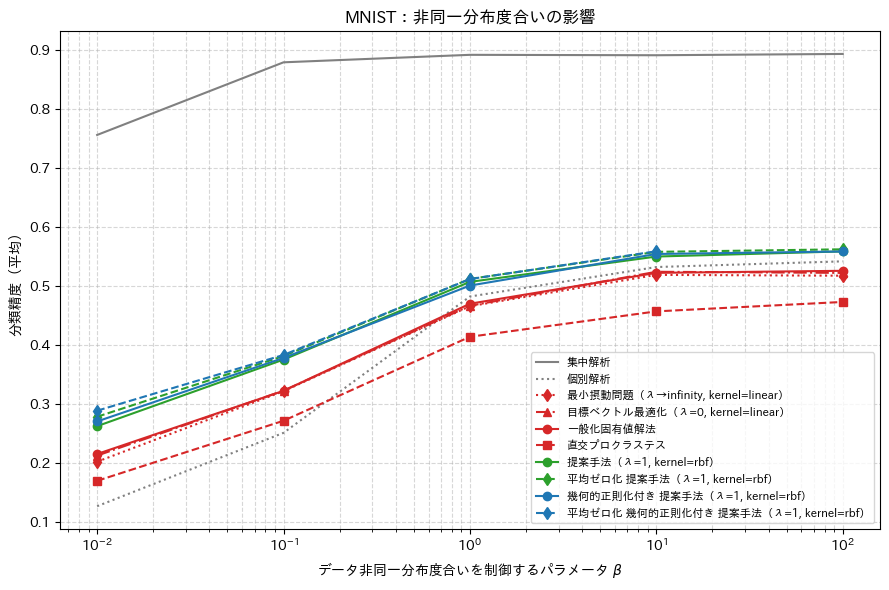

ParserError: Error tokenizing data. C error: Expected 36 fields in line 92, saw 38


In [95]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/0101",
    dataset="MNIST",
    csv_name="result_grid_mnist.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/0101",
    dataset="FASHION_MNIST",
    csv_name="result_grid_fashion_mnist.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/0101",
    dataset="MNIST",
    csv_name="result_grid_mnist.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/0101",
    dataset="FASHION_MNIST",
    csv_name="result_grid_fashion_mnist.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)

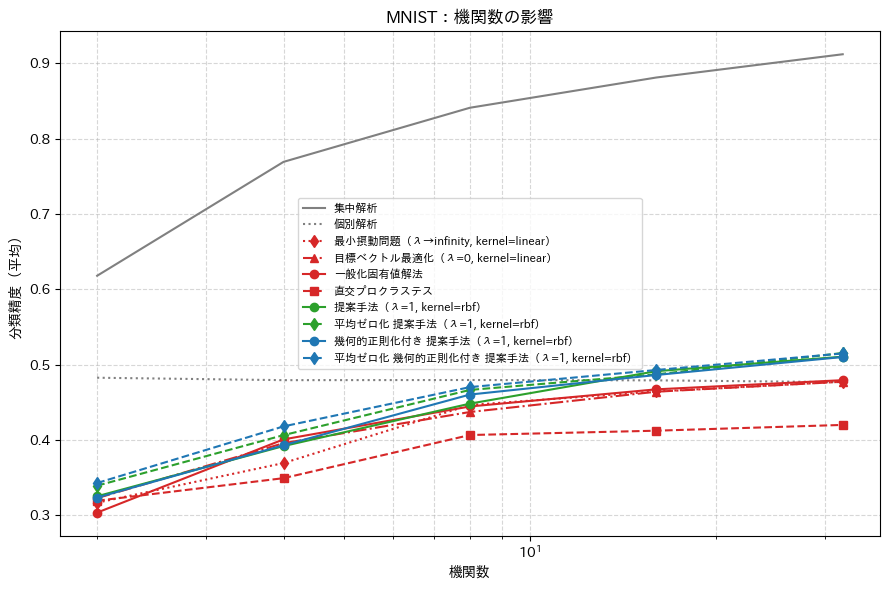

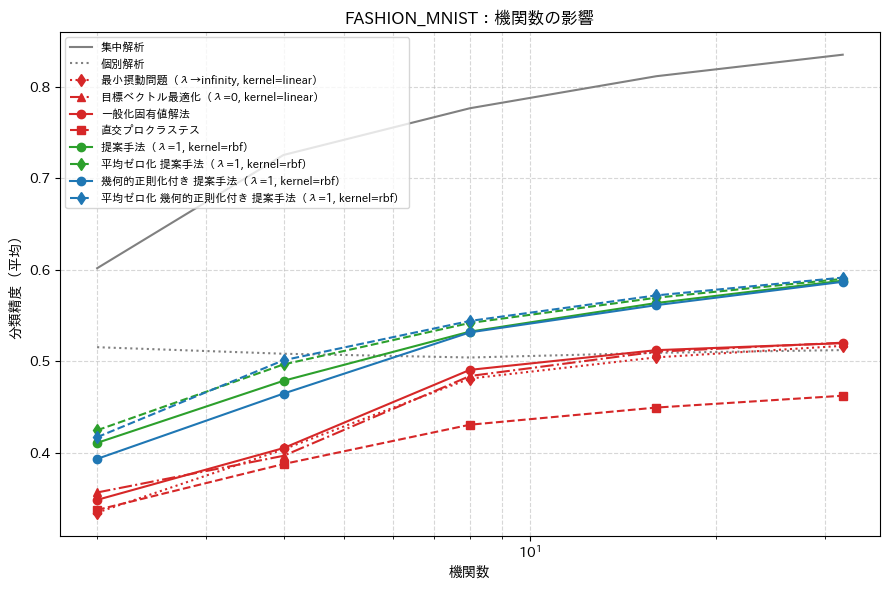

In [113]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept",
    dataset="MNIST",
    csv_name="result_grid_mnist_num_inst.csv",
    x_col="num_institution",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept",
    dataset="FASHION_MNIST",
    csv_name="result_grid_fashion_mnist_num_inst.csv",
    x_col="num_institution",
    defaults=DEFAULTS,
)

In [121]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/0101",
    dataset="MNIST",
    csv_name="result_grid_mnist_rp.csv",
    x_col="sub_dr_ratio",
    defaults=DEFAULTS,
)

KeyError: ['sub_dr_ratio']

<Figure size 900x600 with 0 Axes>

In [ ]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/mnist_experiment_0105",
    dataset="MNIST",
    csv_name="result_grid_mnist.csv",
    x_col="sub_dr_ratio",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/mnist_experiment_0105",
    dataset="FASHION_MNIST",
    csv_name="result_grid_fashion_mnist.csv",
    x_col="sub_dr_ratio",
    defaults=DEFAULTS,
)

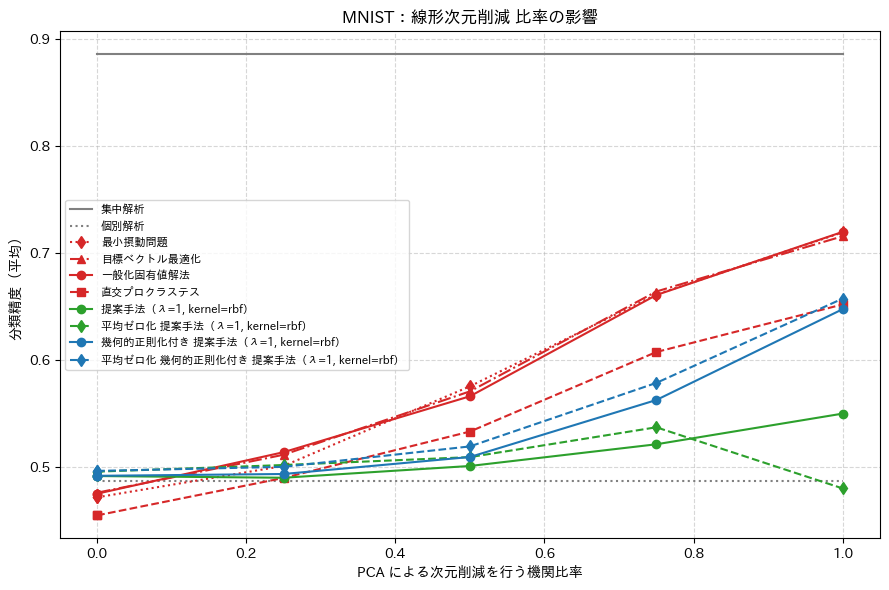

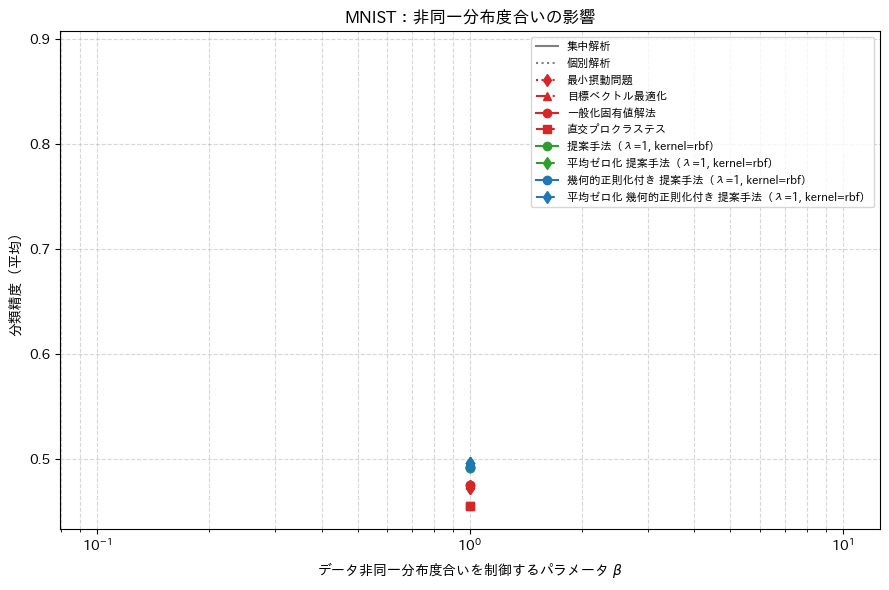

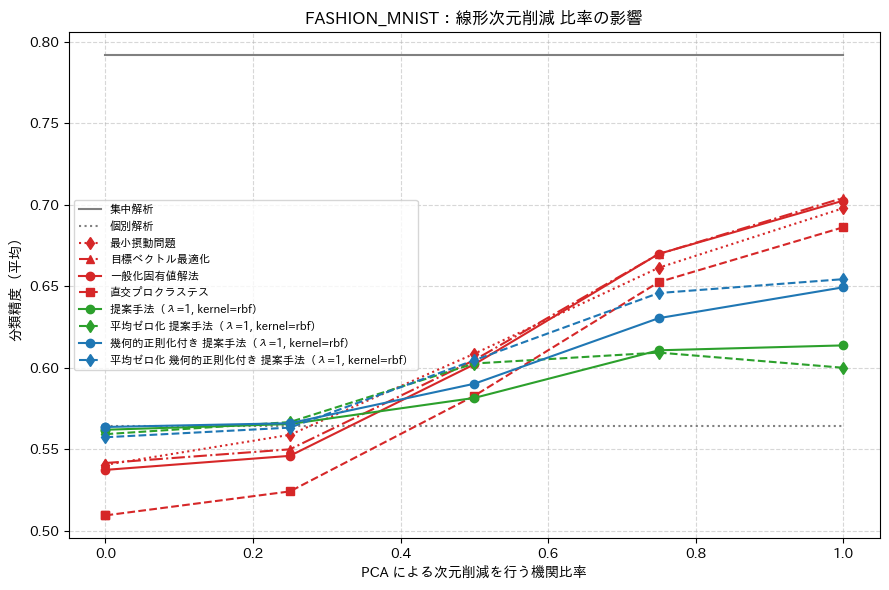

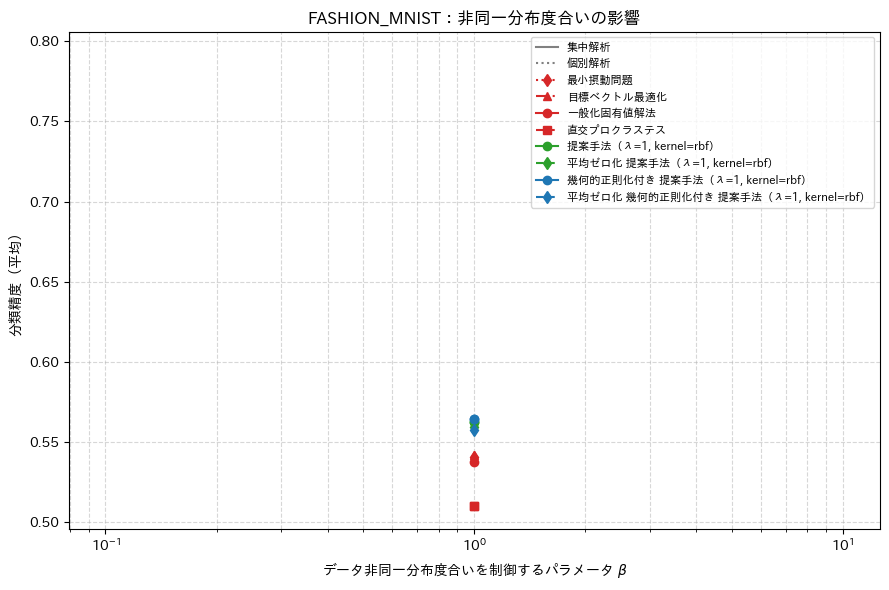

In [155]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/mnist_sub_dr_noniid_0105_K10",
    dataset="MNIST",
    csv_name="result_grid_mnist.csv",
    x_col="sub_dr_ratio",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/mnist_sub_dr_noniid_0105_K10",
    dataset="MNIST",
    csv_name="result_grid_mnist.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/mnist_sub_dr_noniid_0105_K10",
    dataset="FASHION_MNIST",
    csv_name="result_grid_fashion_mnist.csv",
    x_col="sub_dr_ratio",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/mnist_sub_dr_noniid_0105_K10",
    dataset="FASHION_MNIST",
    csv_name="result_grid_fashion_mnist.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)

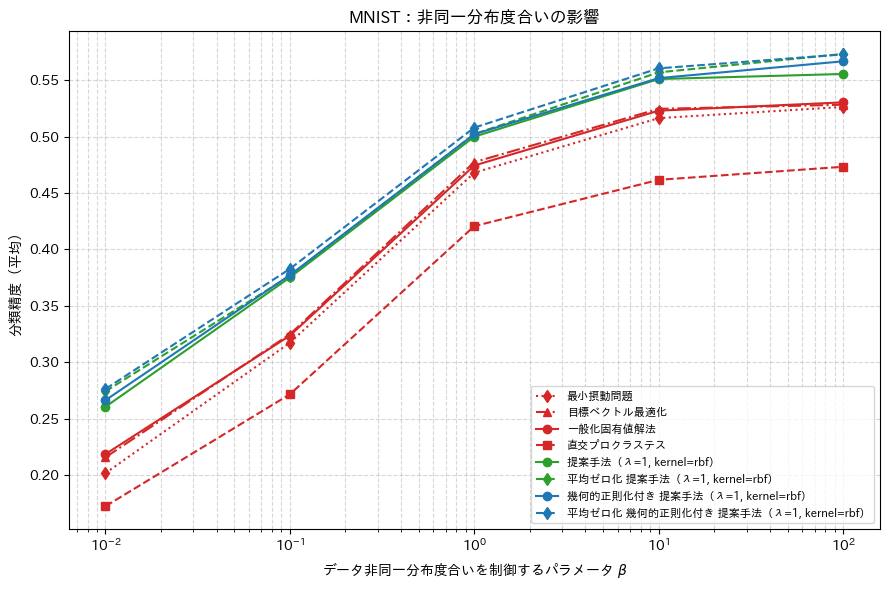

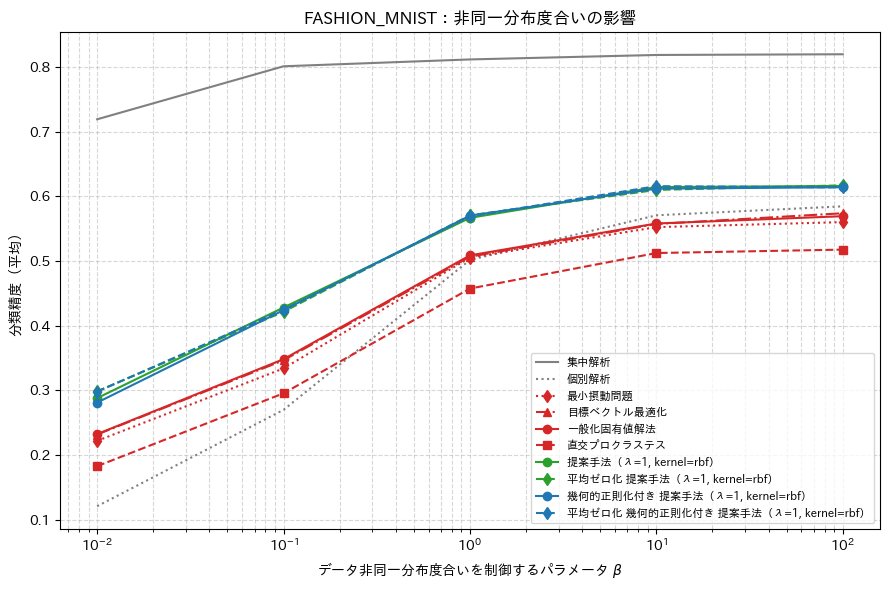

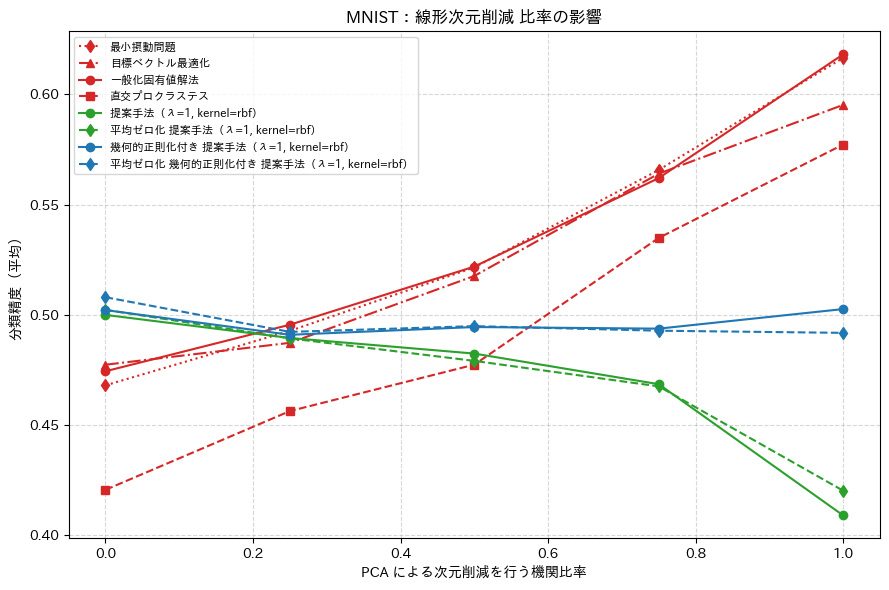

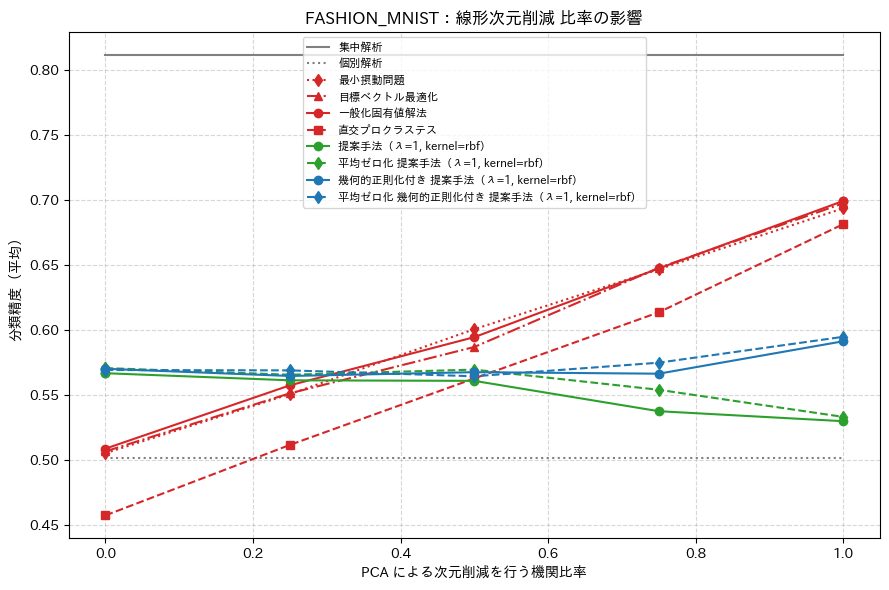

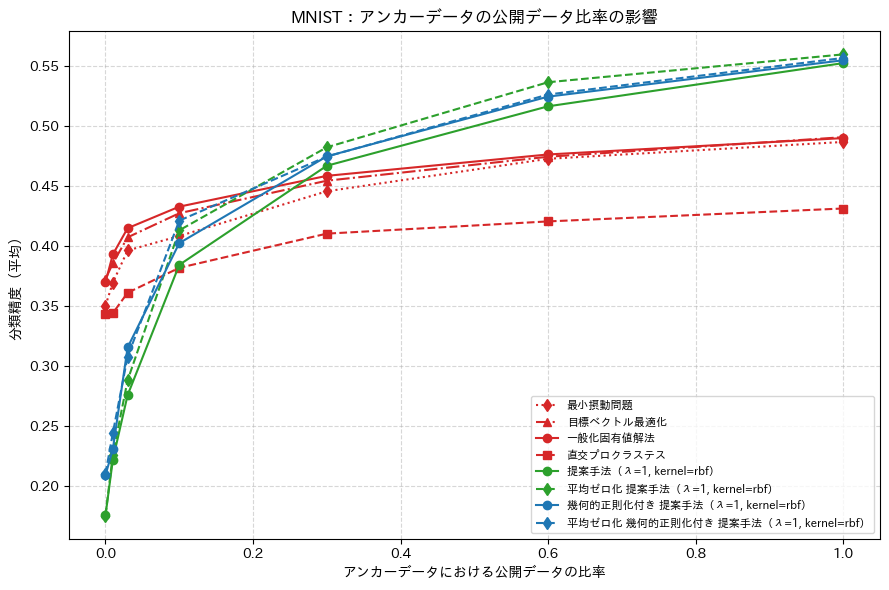

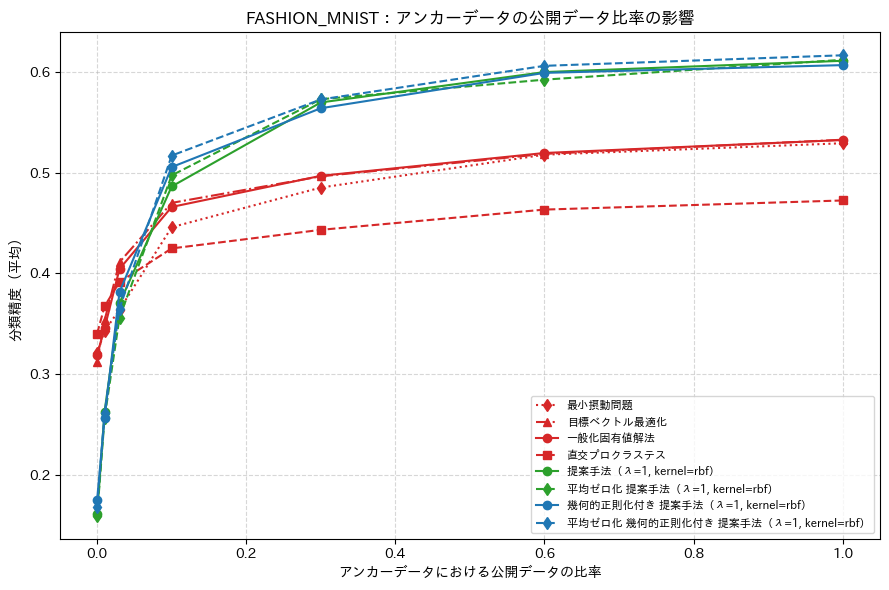

In [118]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept",
    dataset="MNIST",
    csv_name="result_grid_mnist_dir_svd.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept",
    dataset="FASHION_MNIST",
    csv_name="result_grid_fashion_mnist_dir_svd.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept",
    dataset="MNIST",
    csv_name="result_grid_mnist_dir_svd.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept",
    dataset="FASHION_MNIST",
    csv_name="result_grid_fashion_mnist_dir_svd.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept",
    dataset="MNIST",
    csv_name="result_grid_mnist_anchor_concordance.csv",
    x_col="smote_ratio",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept",
    dataset="FASHION_MNIST",
    csv_name="result_grid_fashion_mnist_anchor_concordance.csv",
    x_col="smote_ratio",
    defaults=DEFAULTS,
)

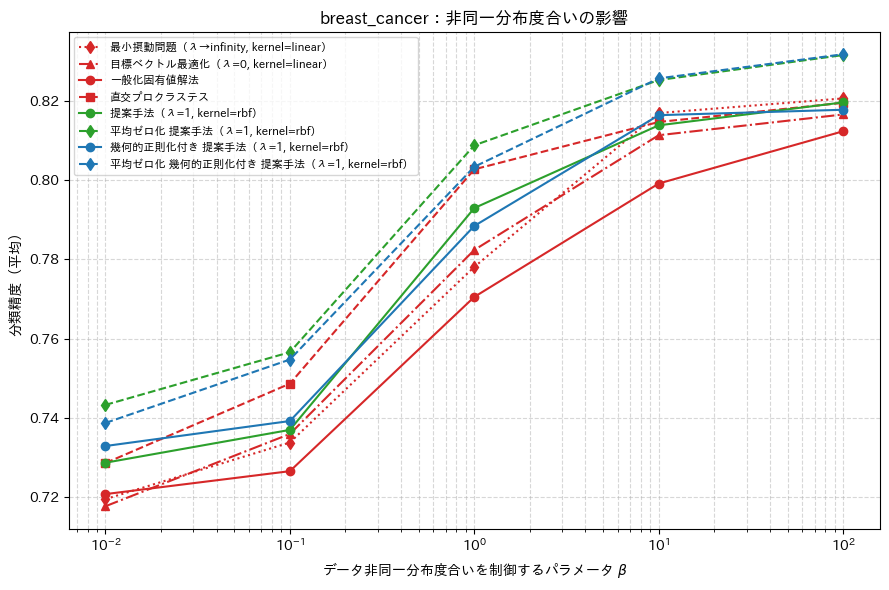

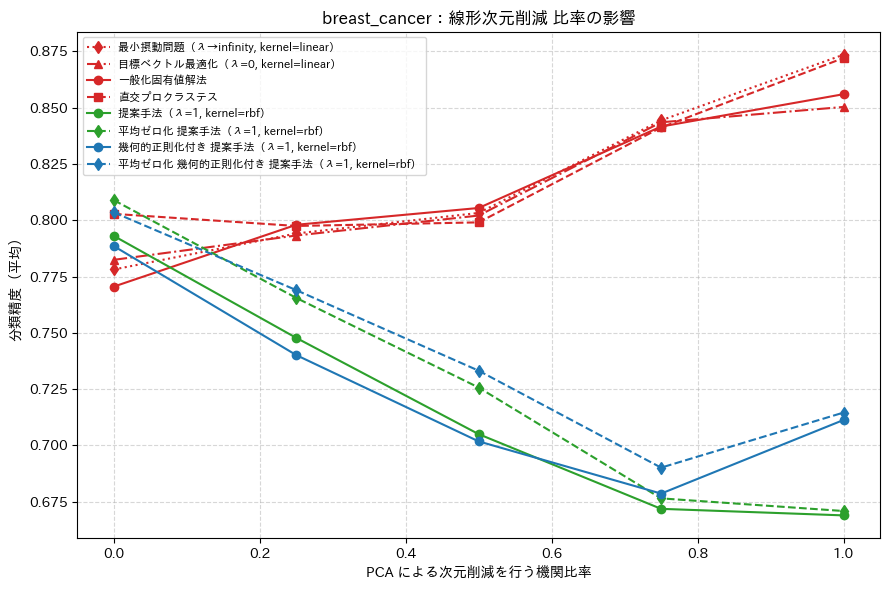

In [56]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept",
    dataset="breast_cancer",
    csv_name="result_grid_breast_cancer_dir_svd.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/accept",
    dataset="breast_cancer",
    csv_name="result_grid_breast_cancer_dir_svd.csv",
    x_col="svd_ratio",
    defaults=DEFAULTS,
)

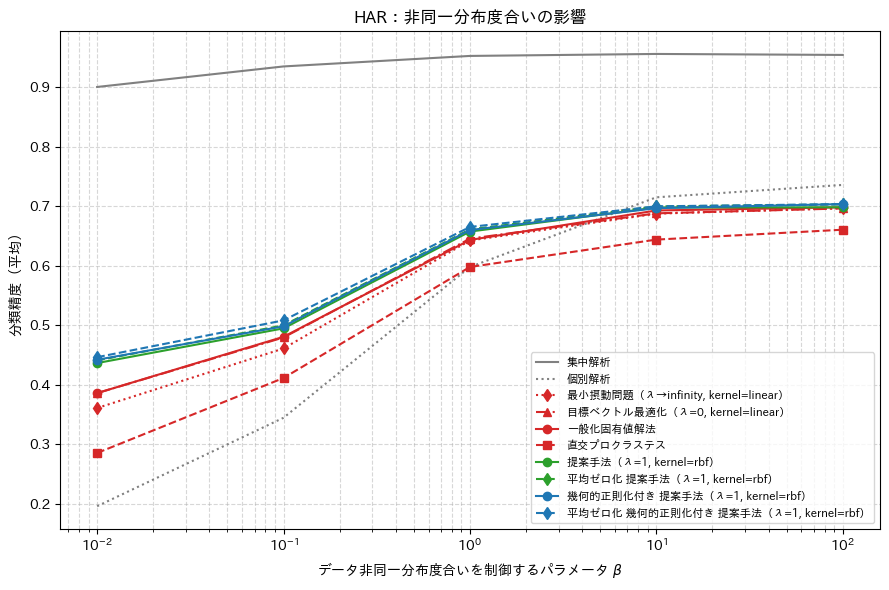

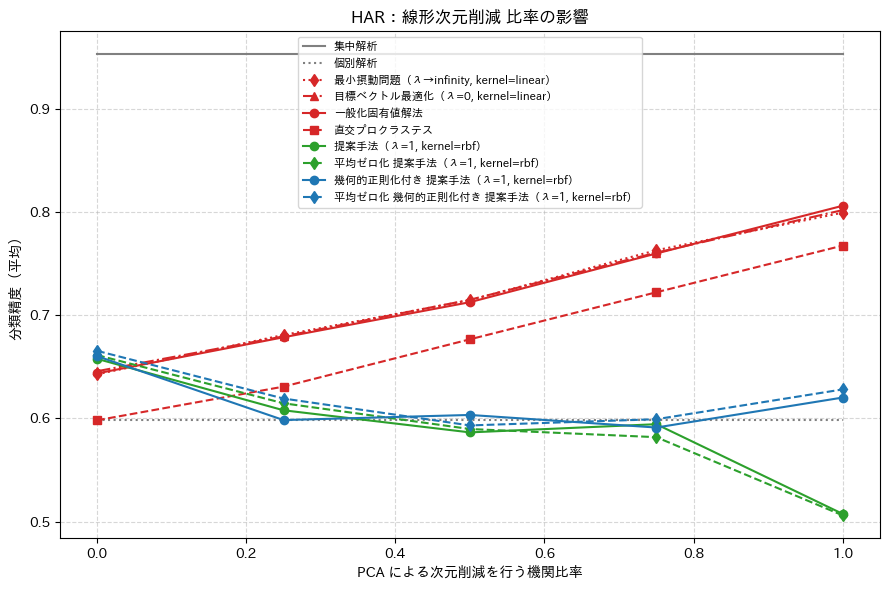

In [109]:
load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/har_svd_nonid_0105",
    dataset="HAR",
    csv_name="result_grid_har.csv",
    x_col="non_iid_beta",
    defaults=DEFAULTS,
)

load_filter_and_plot(
    path=r"/Users/suetake/git-repos/takano_labo/dca/output/har_svd_nonid_0105",
    dataset="HAR",
    csv_name="result_grid_har.csv",
    x_col="sub_dr_ratio",
    defaults=DEFAULTS,
)